In [3]:
# from qiskit_ibm_runtime import QiskitRuntimeService

# QiskitRuntimeService.save_account(
#     channel="ibm_quantum_platform",   # current channel for IBM Quantum Platform accounts
#     token="gAAlXfwwGn5eaDCdg9sPxmkNjgRP8i8kGjcAcqJ5R5vE",
#     instance="crn:v1:bluemix:public:quantum-computing:us-east:a/15e13d02c1c247b09a1ec35d3b96421f:bd32f0fb-256c-4af6-80cd-ea9beeb1e94b::",  # e.g. crn:v1:bluemix:... from your IBM Quantum account page
#     overwrite=True,
# )

# Quantum Phase Estimation
QPE finds the hidden phase $\theta$ in a unitary's eigenvalue equation $U|\psi\rangle=e^{2\pi i\theta}|\psi\rangle$.
It works by phase-kicking $e^{2\pi i\theta \cdot 2^k}$ onto counting qubit $k$ via controlled-$U^{2^k}$, then reading the resulting
Fourier state back out with an inverse QFT — the exact reverse of the frequency-encoding trick from the QFT notebook.
Same setup as before: real backend and a noise-matched simulator, in parallel.

In [4]:
# Connect to IBM Quantum (account already saved earlier)
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

In [5]:
# Pick the real backend and build a Sampler bound to it
from qiskit_ibm_runtime import SamplerV2 as Sampler

backend = service.backend("ibm_marrakesh")
sampler = Sampler(mode=backend)
print(backend.name)

ibm_marrakesh


In [6]:
# Build a local Aer simulator that mimics the backend's noise
from qiskit.primitives import BackendSamplerV2
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

noise_model = NoiseModel.from_backend(backend)
backend_sim = AerSimulator(noise_model=noise_model)
sampler_sim = BackendSamplerV2(backend=backend_sim)

In [7]:
# Inverse QFT: reverse of the QFT notebook's circuit, used to decode the phase-kicked counting register
from math import pi
from qiskit import QuantumCircuit

def iqft(n: int) -> QuantumCircuit:
    qc = QuantumCircuit(n)
    for i in range(n // 2):
        qc.swap(i, n - 1 - i)                # undo the QFT's final bit-reversal first
    for k in range(n):
        for q in range(k):
            qc.cp(-pi / 2 ** (k - q), q, k)   # negated phase kicks, reverse order
        qc.h(k)
    return qc

In [8]:
# The unitary whose eigenphase we want to recover: U|1> = e^{2*pi*i*theta}|1>
theta = 5 / 16                               # exactly representable with a 4-qubit counting register
n = 4                                        # counting qubits -> 2**n possible phase estimates

def controlled_u_power(power: int) -> QuantumCircuit:
    qc = QuantumCircuit(1)
    qc.p(2 * pi * theta * power, 0)          # U^power = P(2*pi*theta*power) on the eigenvector
    return qc.control(1)

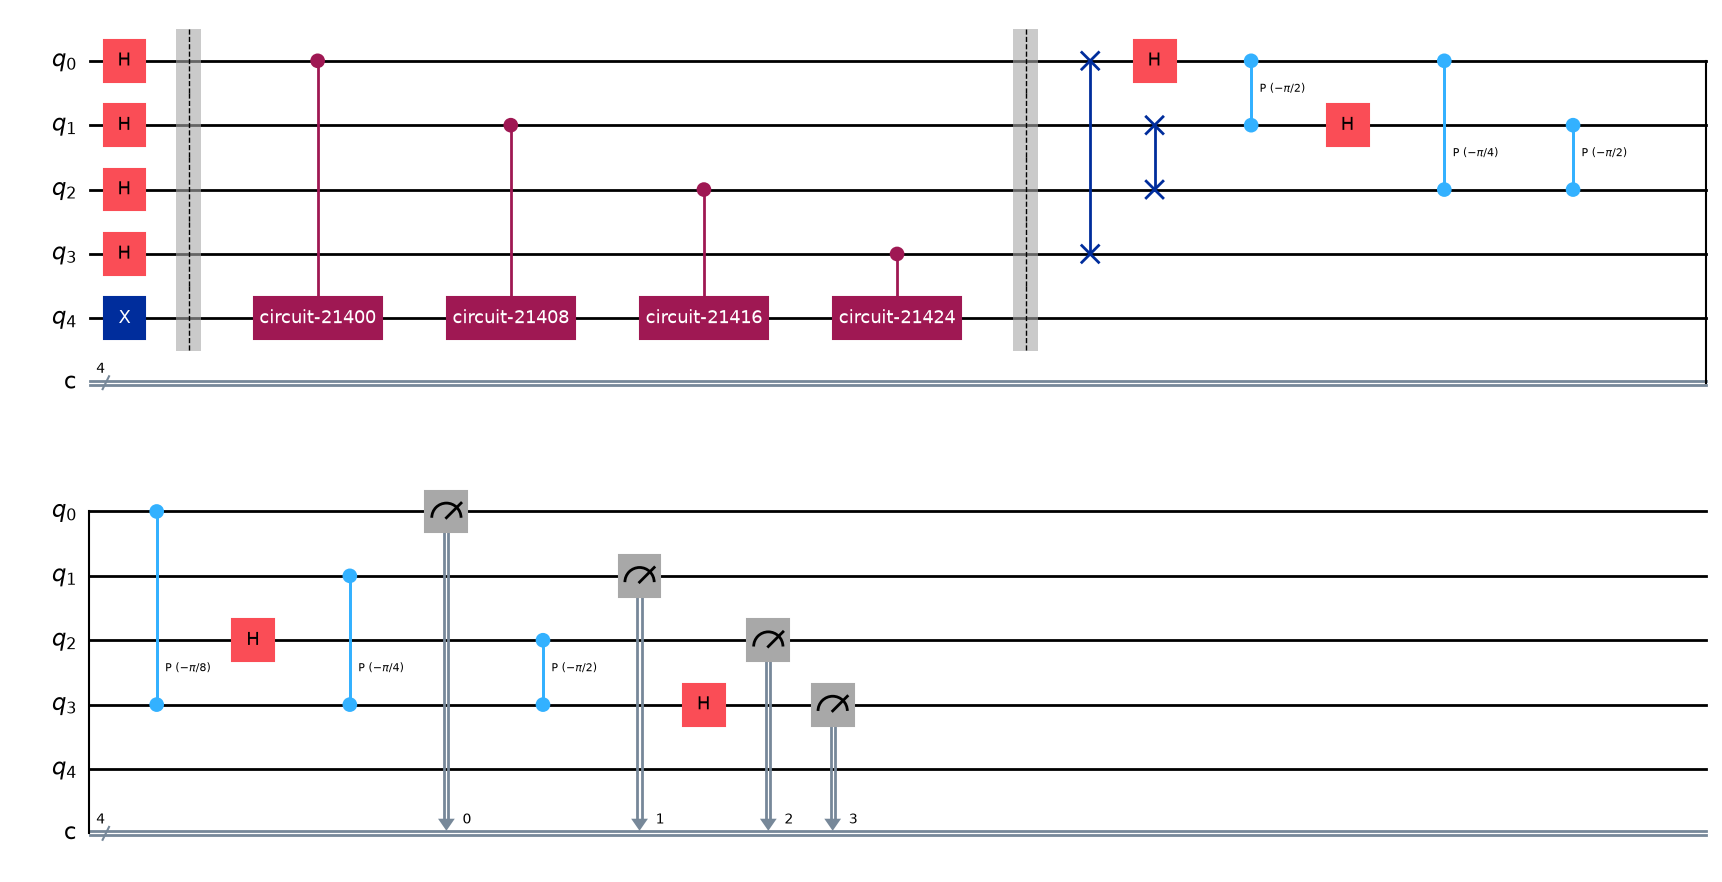

In [9]:
# Full QPE circuit: counting register in superposition, controlled-U^(2^k) phase kickback, then inverse QFT
counting = list(range(n))
target = n                                   # single target qubit, index n

qc = QuantumCircuit(n + 1, n)
qc.h(counting)                               # superposition over every possible x
qc.x(target)                                 # prepare the eigenvector |1>
qc.barrier()
for k in counting:
    qc.compose(controlled_u_power(2 ** k), [k, target], inplace=True)  # phase kickback of theta * 2**k
qc.barrier()
qc.compose(iqft(n), counting, inplace=True)  # decode the phases back into a binary estimate of theta
qc.measure(counting, counting)

qc.draw("mpl")

In [10]:
# Transpile to the backend's native gates/qubits (ISA circuit)
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pm = generate_preset_pass_manager(target=backend.target, optimization_level=3)
qc_isa = pm.run(qc)

In [11]:
# Submit both jobs first so they run in parallel, then collect results
job_real = sampler.run([qc_isa], shots=1024)
job_sim = sampler_sim.run([qc_isa], shots=1024)

counts_real = job_real.result()[0].data.c.get_counts()
counts_sim = job_sim.result()[0].data.c.get_counts()

theta         : 0.3125 = 5 / 16
sim  peak     : 0101 = 5 -> 0.3125
real peak     : 0101 = 5 -> 0.3125


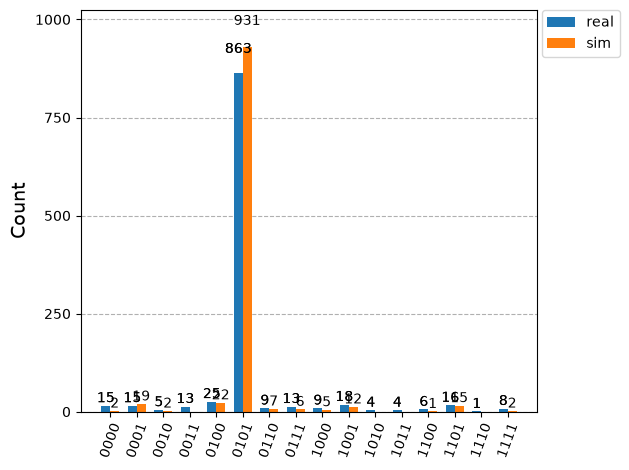

In [12]:
# The dominant bitstring, read as an integer m, should satisfy theta ~= m / 2**n
from qiskit.visualization import plot_histogram

peak_sim = max(counts_sim, key=counts_sim.get)
peak_real = max(counts_real, key=counts_real.get)
print("theta         :", theta, "=", int(theta * 2 ** n), "/", 2 ** n)
print("sim  peak     :", peak_sim, "=", int(peak_sim, 2), "->", int(peak_sim, 2) / 2 ** n)
print("real peak     :", peak_real, "=", int(peak_real, 2), "->", int(peak_real, 2) / 2 ** n)
plot_histogram([counts_real, counts_sim], legend=["real", "sim"])

## What the results mean

**The single peak at `0101` (= 5).** We built a unitary $U=P(2\pi\theta)$ with $\theta=5/16$ and an eigenvector $|1\rangle$. Each controlled-$U^{2^k}$ kicks back a phase of $\theta\cdot 2^k$ onto counting qubit $k$, leaving the counting register in exactly the Fourier state that the QFT notebook produced from a plane wave of frequency $f=5$. The inverse QFT undoes that encoding, so measuring the counting register returns the integer $m=2^n\theta=5$ almost every time — dividing by $2^n=16$ hands back our original $\theta=5/16$ exactly.

**Why this matters more than it looks.** QPE is the reason the QFT exists at all in most quantum algorithms. Shor's algorithm is QPE applied to modular exponentiation; quantum chemistry ground-state energy estimation is QPE applied to a Hamiltonian's time-evolution operator. Swap out the toy phase gate here for any unitary with a computable controlled-power, and this same circuit becomes the engine of both.

**Real vs. sim.** With a 4-qubit counting register and $\theta$ exactly representable in 4 bits, the noiseless math gives a single peak with probability 1. On hardware the controlled-$U^{2^k}$ gates chain into more two-qubit gates as $k$ grows (the last one alone is a controlled phase applied 8 times over), so expect the real peak to still land on `0101` but with amplitude leaking into neighbors like `0100` or `0110` — an off-by-one error in the estimated phase. The noise-matched simulator should predict roughly the same spread; if it doesn't, the mismatch is a clue about which gate in the circuit is the dominant error source.